In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/student_dropout_project"

os.makedirs(project_path + "/data", exist_ok=True)
os.makedirs(project_path + "/models", exist_ok=True)

print("Folders created successfully ✅")

Folders created successfully ✅


In [ ]:
!pip install xgboost seaborn matplotlib scikit-learn tensorflow

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving student dropout.csv to student dropout.csv


In [ ]:
import pandas as pd

df = pd.read_csv("student dropout.csv")
df.head()

,School,Gender,Age,Address,Family_Size,Parental_Status,Mother_Education,Father_Education,Mother_Job,Father_Job,...,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Number_of_Absences,Grade_1,Grade_2,Final_Grade,Dropped_Out
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,4,0,11,11,False
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,2,9,11,11,False
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,6,12,13,12,False
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,0,14,14,14,False
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,0,11,13,13,False


In [ ]:
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   School                       649 non-null    object
 1   Gender                       649 non-null    object
 2   Age                          649 non-null    int64 
 3   Address                      649 non-null    object
 4   Family_Size                  649 non-null    object
 5   Parental_Status              649 non-null    object
 6   Mother_Education             649 non-null    int64 
 7   Father_Education             649 non-null    int64 
 8   Mother_Job                   649 non-null    object
 9   Father_Job                   649 non-null    object
 10  Reason_for_Choosing_School   649 non-null    object
 11  Guardian                     649 non-null    object
 12  Travel_Time                  649 non-null    int64 
 13  Study_Time                   649 no

,School,Gender,Age,Address,Family_Size,Parental_Status,Mother_Education,Father_Education,Mother_Job,Father_Job,...,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Number_of_Absences,Grade_1,Grade_2,Final_Grade,Dropped_Out
count,649,649,649.000000,649,649,649,649.000000,649.000000,649,649,...,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649
unique,2,2,NaN,2,2,2,NaN,NaN,5,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,GP,F,NaN,U,GT3,T,NaN,NaN,other,other,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,423,383,NaN,452,457,569,NaN,NaN,258,367,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,549
mean,NaN,NaN,16.744222,NaN,NaN,NaN,2.514638,2.306626,NaN,NaN,...,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009,NaN
std,NaN,NaN,1.218138,NaN,NaN,NaN,1.134552,1.099931,NaN,NaN,...,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656,NaN
min,NaN,NaN,15.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,16.000000,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN,...,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000,NaN
50%,NaN,NaN,17.000000,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,...,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000,NaN
75%,NaN,NaN,18.000000,NaN,NaN,NaN,4.000000,3.000000,NaN,NaN,...,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000,NaN


In [ ]:
df.head()

,School,Gender,Age,Address,Family_Size,Parental_Status,Mother_Education,Father_Education,Mother_Job,Father_Job,...,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Number_of_Absences,Grade_1,Grade_2,Final_Grade,Dropped_Out
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,4,0,11,11,False
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,2,9,11,11,False
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,6,12,13,12,False
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,0,14,14,14,False
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,0,11,13,13,False


In [ ]:
df.isnull().sum()

,0
School,0
Gender,0
Age,0
Address,0
Family_Size,0
Parental_Status,0
Mother_Education,0
Father_Education,0
Mother_Job,0
Father_Job,0


In [ ]:
df.notnull().count()

,0
School,649
Gender,649
Age,649
Address,649
Family_Size,649
Parental_Status,649
Mother_Education,649
Father_Education,649
Mother_Job,649
Father_Job,649


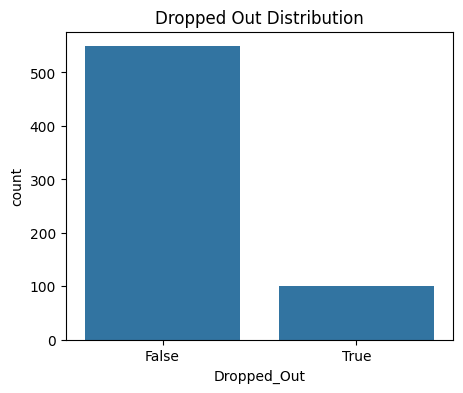

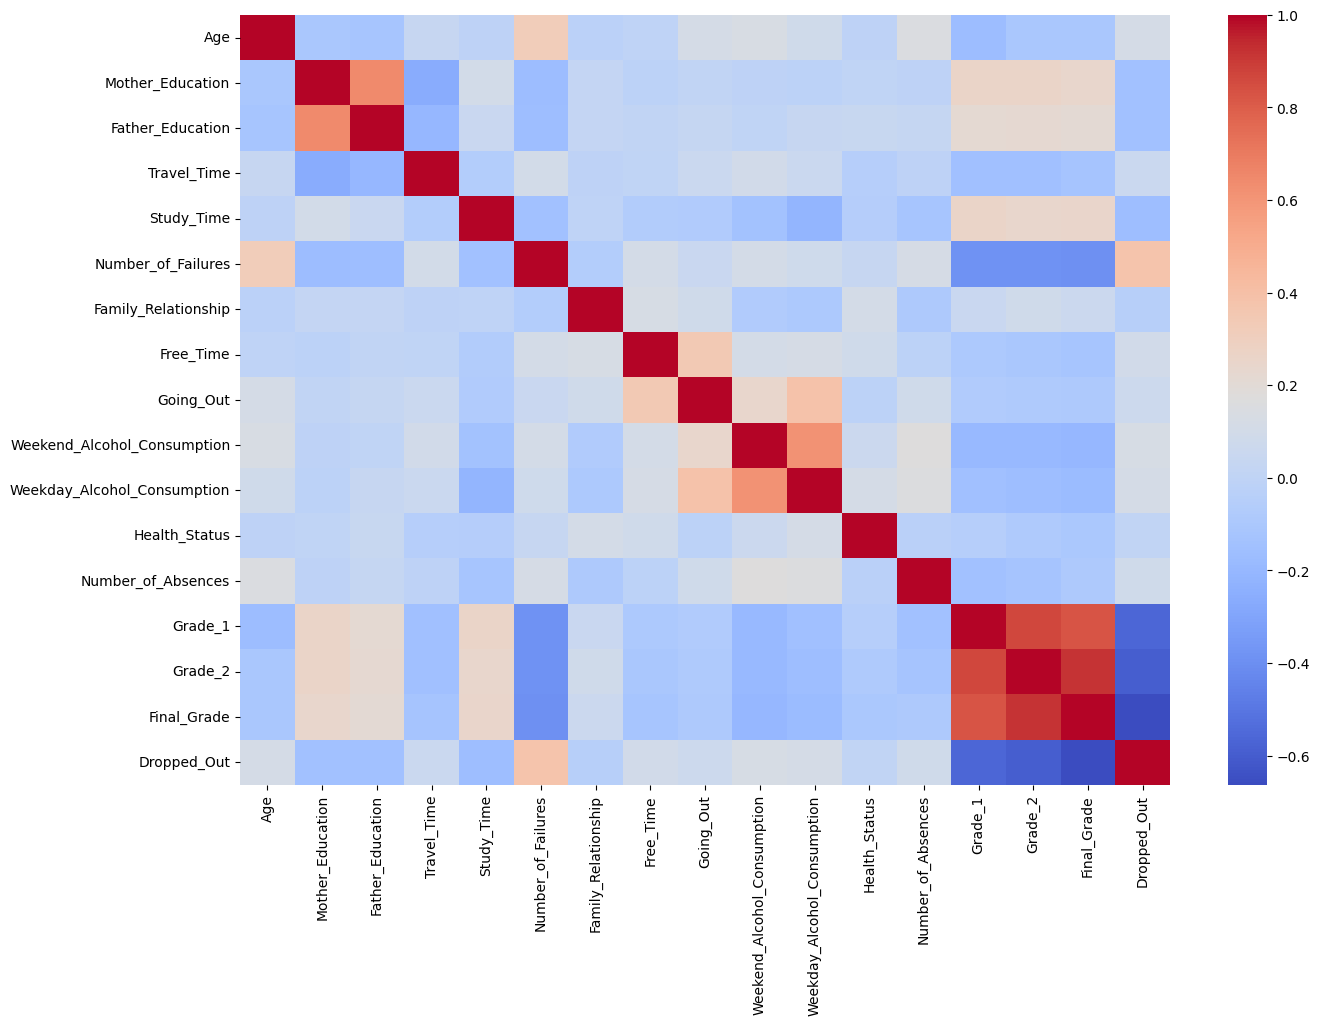

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.countplot(x=df["Dropped_Out"])
plt.title("Dropped Out Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.show()

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,649.0,16.744222,1.218138,15.0,16.0,17.0,18.0,22.0
Mother_Education,649.0,2.514638,1.134552,0.0,2.0,2.0,4.0,4.0
Father_Education,649.0,2.306626,1.099931,0.0,1.0,2.0,3.0,4.0
Travel_Time,649.0,1.568567,0.748660,1.0,1.0,1.0,2.0,4.0
Study_Time,649.0,1.930663,0.829510,1.0,1.0,2.0,2.0,4.0
Number_of_Failures,649.0,0.221880,0.593235,0.0,0.0,0.0,0.0,3.0
Family_Relationship,649.0,3.930663,0.955717,1.0,4.0,4.0,5.0,5.0
Free_Time,649.0,3.180277,1.051093,1.0,3.0,3.0,4.0,5.0
Going_Out,649.0,3.184900,1.175766,1.0,2.0,3.0,4.0,5.0
Weekend_Alcohol_Consumption,649.0,1.502311,0.924834,1.0,1.0,1.0,2.0,5.0


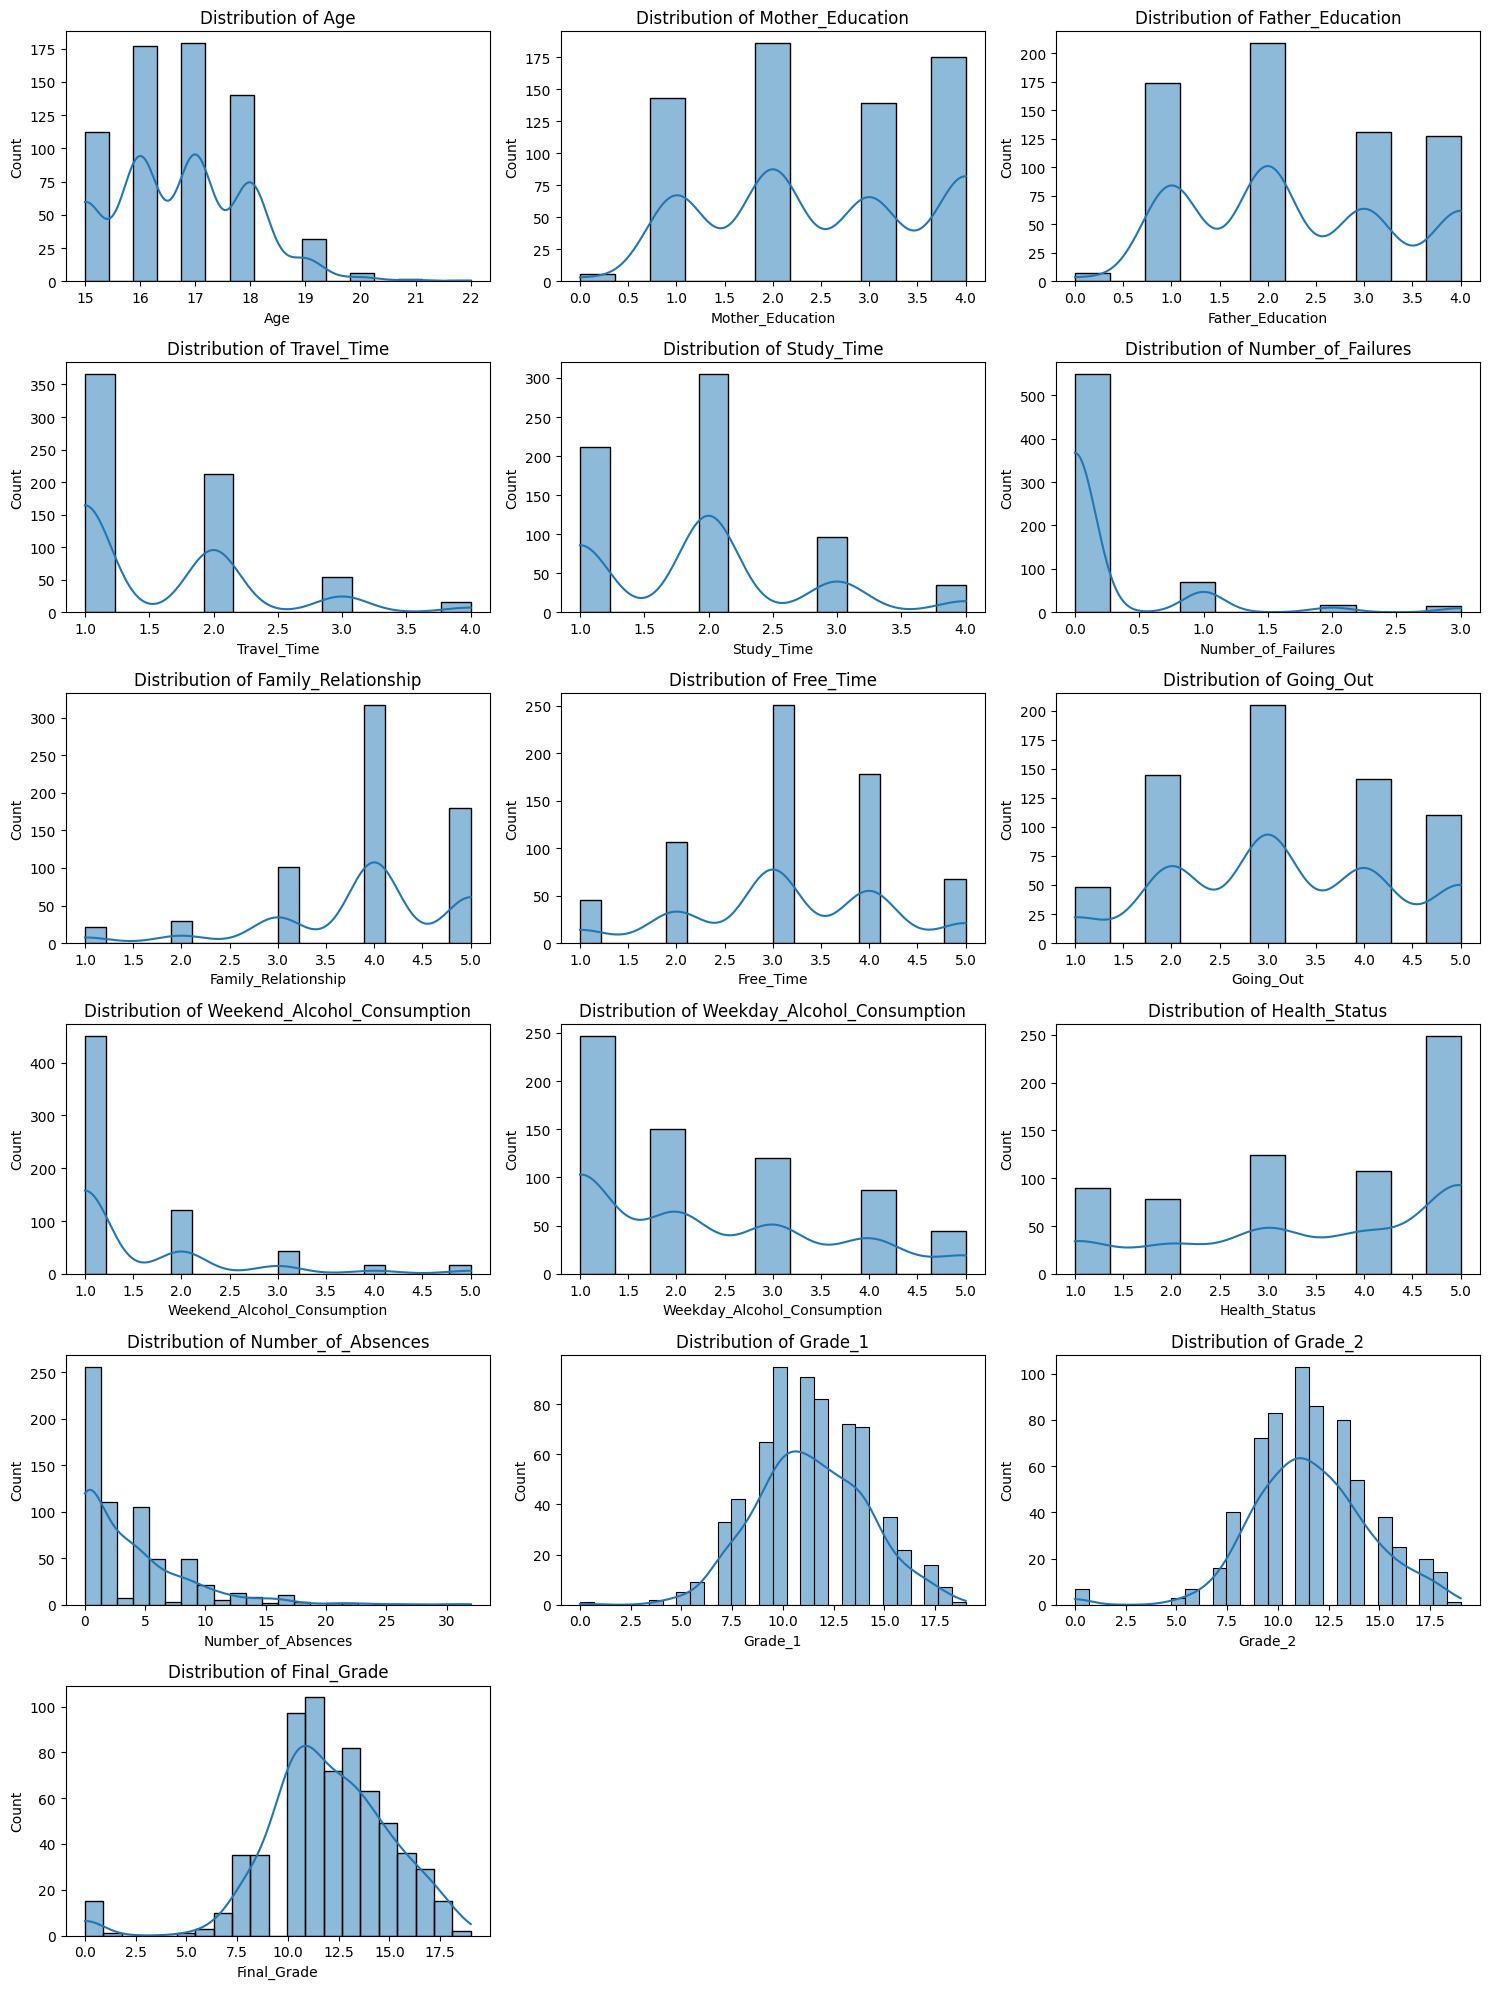

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 20))
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols)//3 + 1, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

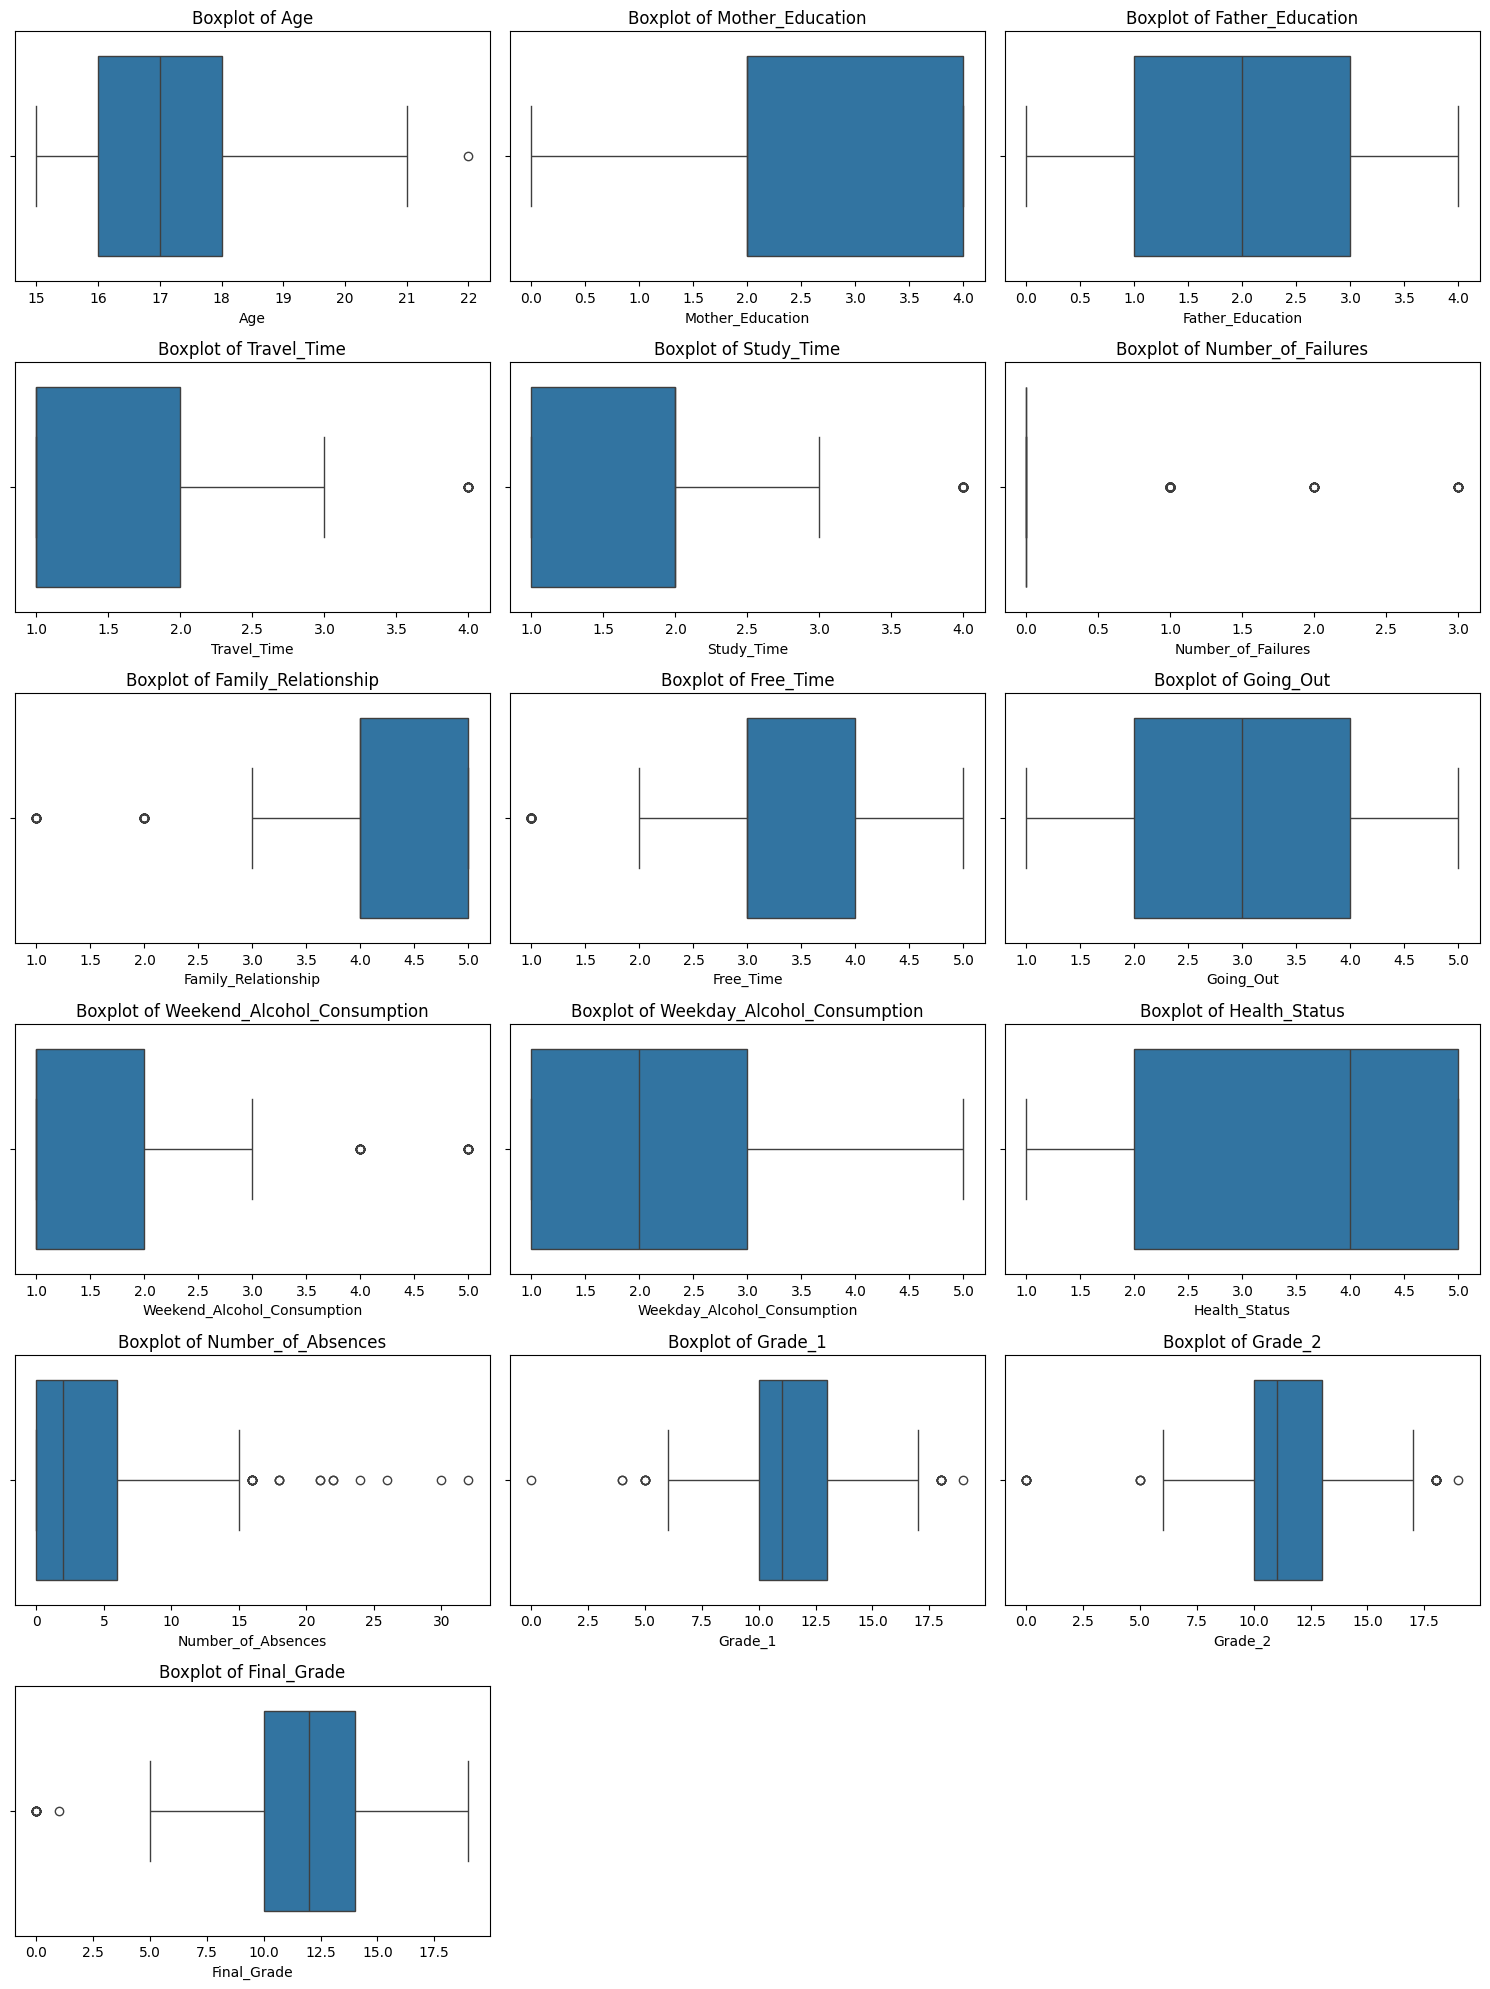

In [ ]:
plt.figure(figsize=(15, 20))
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols)//3 + 1, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

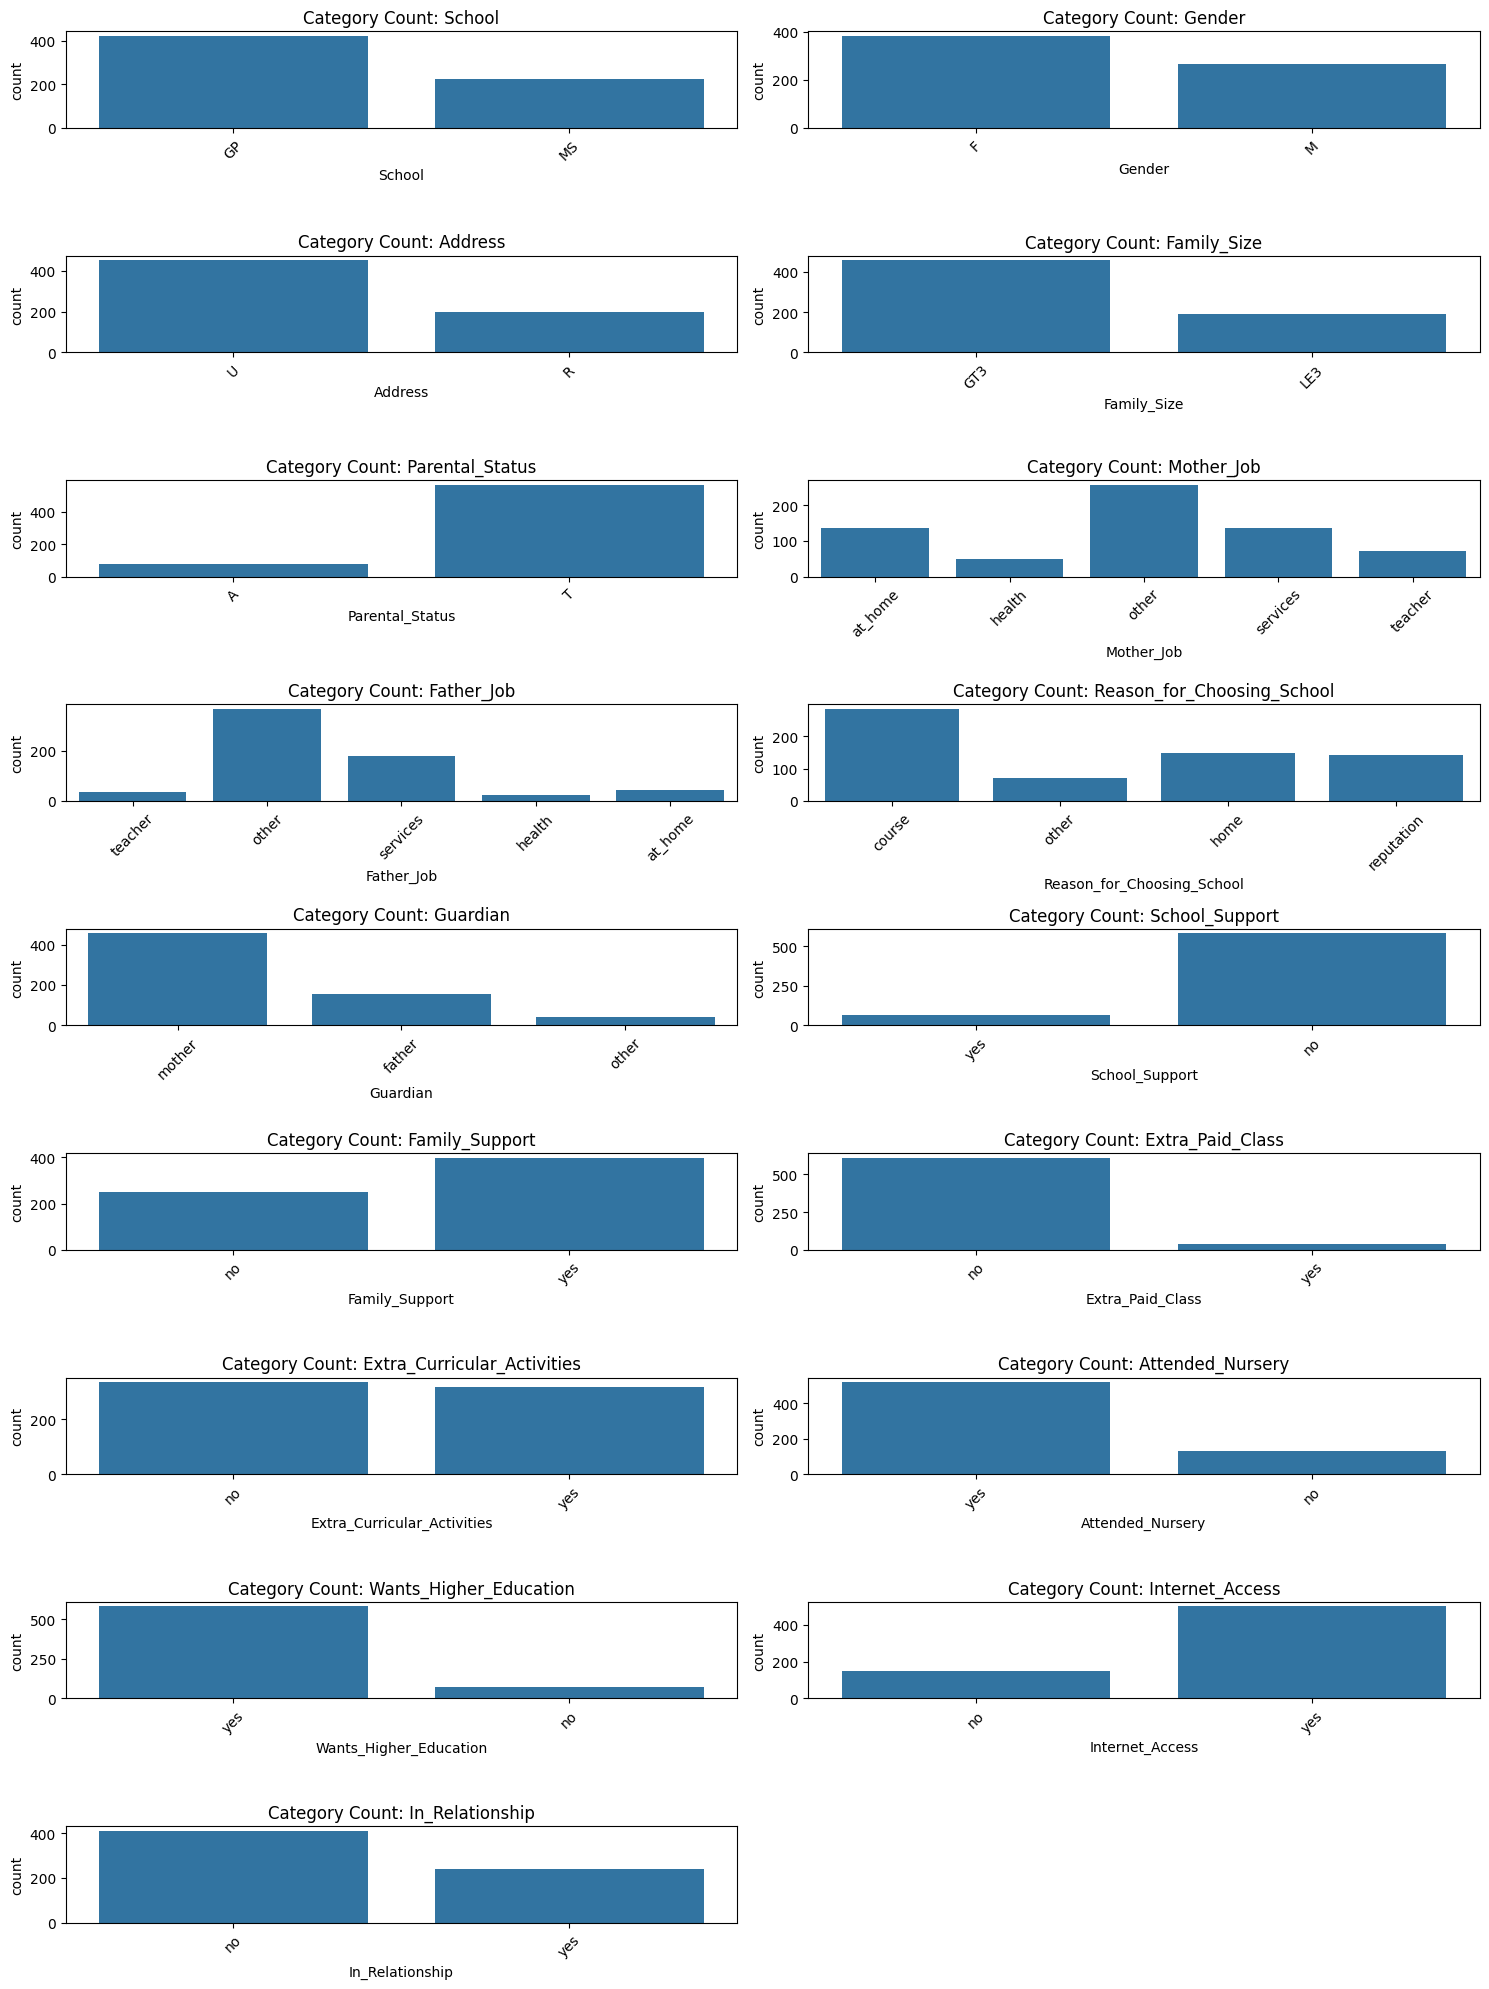

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns

plt.figure(figsize=(15, 20))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(len(cat_cols)//2 + 1, 2, i)
    sns.countplot(x=df[col])
    plt.title(f"Category Count: {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

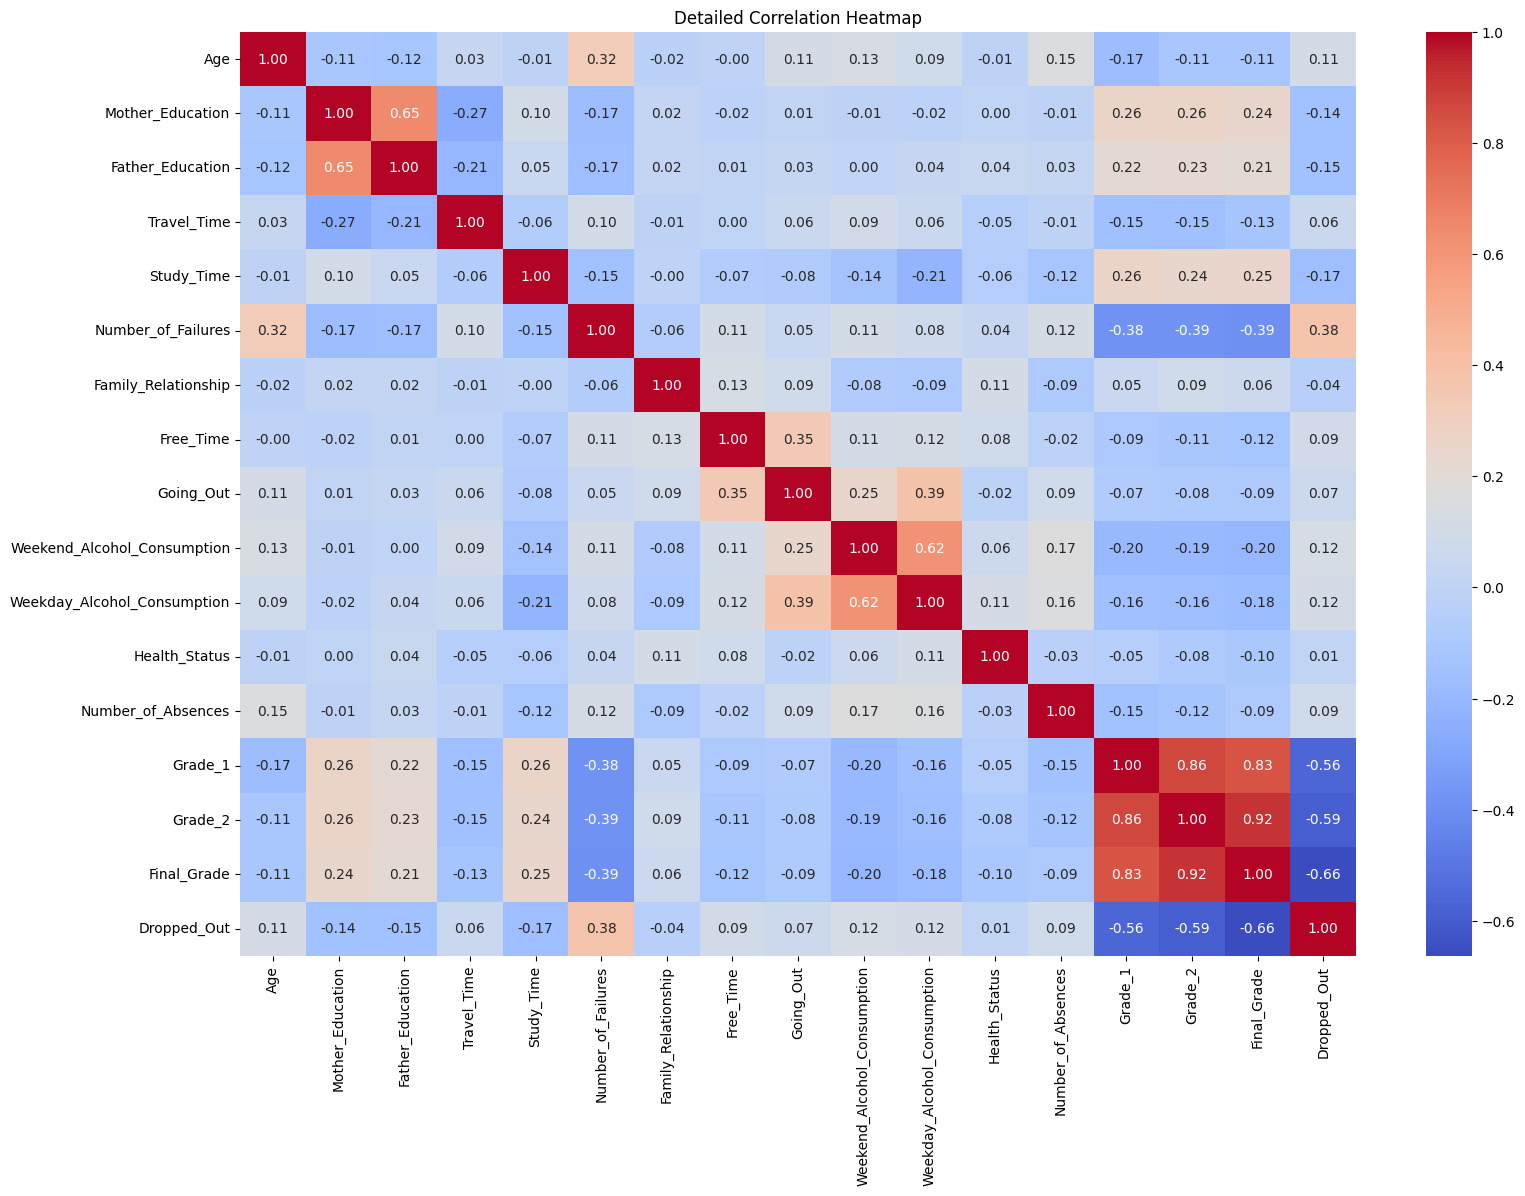

In [ ]:
plt.figure(figsize=(18, 12))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Detailed Correlation Heatmap")
plt.show()

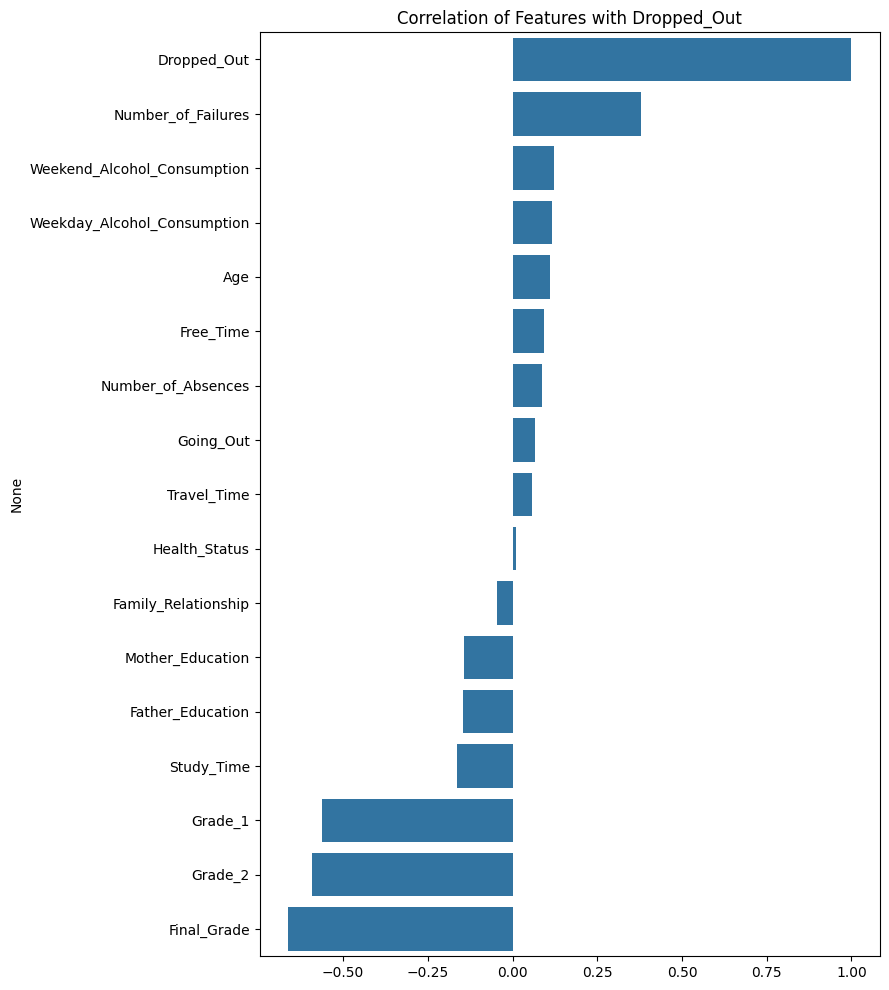

,Dropped_Out
Dropped_Out,1.000000
Number_of_Failures,0.380237
Weekend_Alcohol_Consumption,0.123627
Weekday_Alcohol_Consumption,0.116249
Age,0.110722
Free_Time,0.093349
Number_of_Absences,0.087483
Going_Out,0.067241
Travel_Time,0.057869
Health_Status,0.009979


In [ ]:
target_corr = df.corr(numeric_only=True)["Dropped_Out"].sort_values(ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(y=target_corr.index, x=target_corr.values)
plt.title("Correlation of Features with Dropped_Out")
plt.show()

target_corr

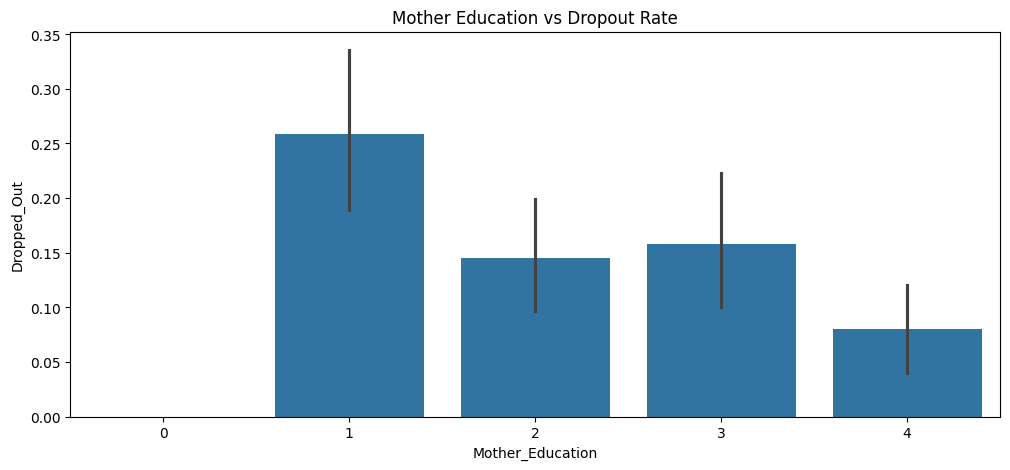

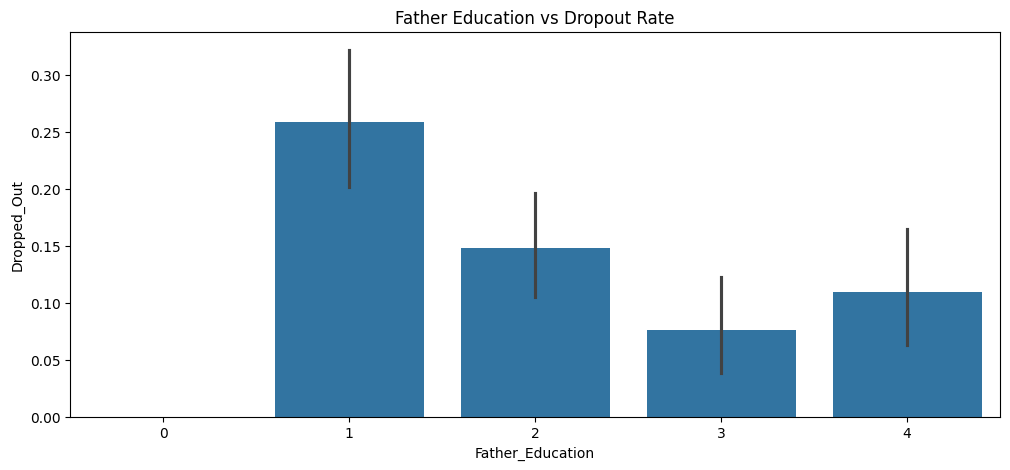

In [ ]:
plt.figure(figsize=(12,5))
sns.barplot(x=df["Mother_Education"], y=df["Dropped_Out"])
plt.title("Mother Education vs Dropout Rate")
plt.show()

plt.figure(figsize=(12,5))
sns.barplot(x=df["Father_Education"], y=df["Dropped_Out"])
plt.title("Father Education vs Dropout Rate")
plt.show()

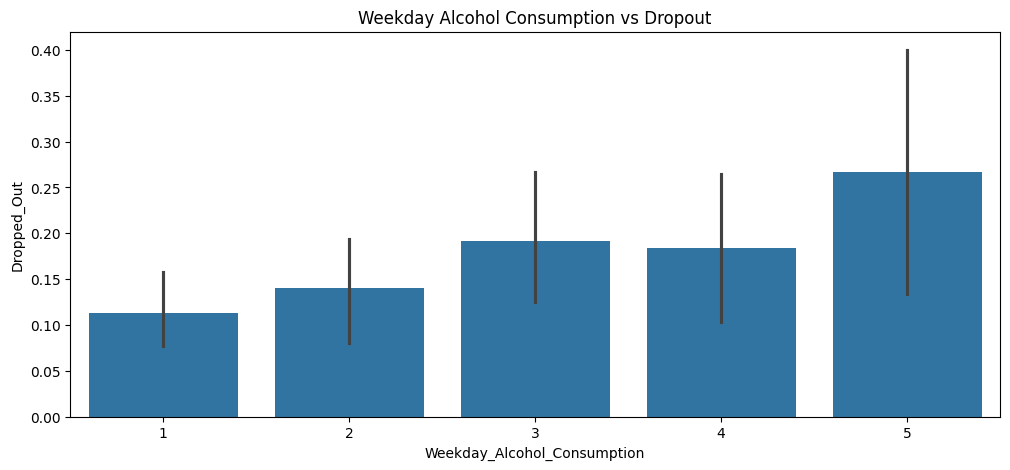

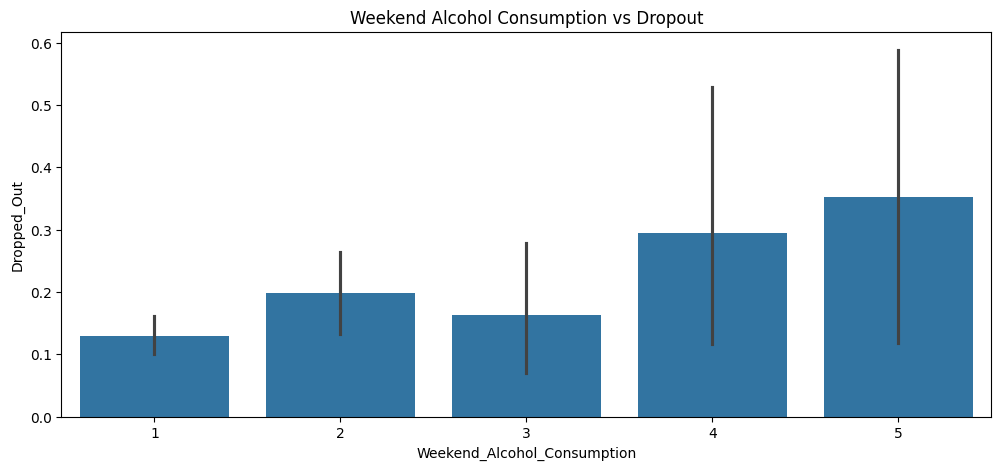

In [ ]:
plt.figure(figsize=(12,5))
sns.barplot(
    x=df["Weekday_Alcohol_Consumption"],
    y=df["Dropped_Out"]
)
plt.title("Weekday Alcohol Consumption vs Dropout")
plt.show()

plt.figure(figsize=(12,5))
sns.barplot(
    x=df["Weekend_Alcohol_Consumption"],
    y=df["Dropped_Out"]
)
plt.title("Weekend Alcohol Consumption vs Dropout")
plt.show()

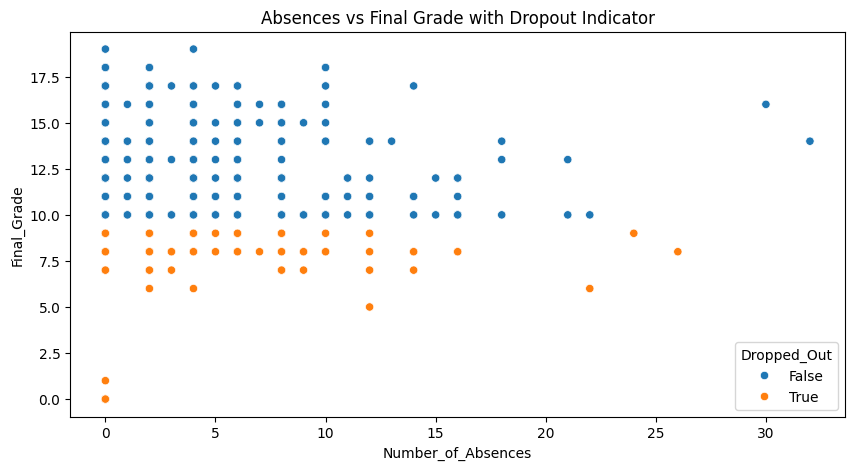

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    x=df["Number_of_Absences"],
    y=df["Final_Grade"],
    hue=df["Dropped_Out"]
)
plt.title("Absences vs Final Grade with Dropout Indicator")
plt.show()

In [ ]:
df.to_csv("data/cleaned_data.csv", index=False)

In [ ]:
import os
os.makedirs("data", exist_ok=True)

In [ ]:
df.to_csv("/content/drive/MyDrive/student_dropout_project/data/cleaned_data.csv", index=False)
print("Saved successfully ✅")

Saved successfully ✅
